In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(palette="deep")

In [91]:
data = pd.read_csv(r"data.csv", dtype = {"link_flair_text": "string"})

data["date"] = pd.to_datetime(pd.to_numeric(data["created_utc"], errors="coerce"), unit="s")
data["year"]  = data["date"].dt.year
data["month"] = data["date"].dt.to_period("M")

data["type"] = data["plik"].str.split("_").str[2]

data = data[[
    "type",
    # "plik",
    # "created_utc",
    "date",
    "year",
    "month",
    "subreddit",
    # "subreddit_id",
    "id",
    "parent_id",
    # "link_id",
    "author",
    # "over_18",
    "body",
    "title",
    # "ups",
    # "downs",
    "score"
]]

data.head(2)

,type,date,year,month,subreddit,id,parent_id,author,body,title,score
0,comments,2017-06-13 03:28:38,2017,2017-06,Cyrus,dittstm,t3_6gvhln,cysenberg,I can't believe this sub is devoted to that ho...,NaN,1
1,comments,2017-06-13 03:58:09,2017,2017-06,Cyrus,ditveid,t1_dittstm,cy_guy,?? what did ido???,NaN,1


In [44]:
data.isnull().sum() # zgadza się wszystko

type             0
date             0
year             0
month            0
subreddit        0
id               0
parent_id    24090
author           0
body         24090
title        84750
score            0
dtype: int64

## 1. Zliczenie wierszy dla subredditów i typu (post, komentarz)

In [73]:
subreddit_type_count = data.pivot_table(
    index="subreddit",
    columns="type",
    values="id",
    aggfunc="count",
    fill_value=0
)
subreddit_type_count["TOTAL"] = subreddit_type_count.sum(axis=1)
subreddit_type_count = subreddit_type_count.sort_values(by="TOTAL", ascending=False)
subreddit_type_count.loc["TOTAL"] = subreddit_type_count.sum(numeric_only=True)

subreddit_type_count

type,comments,posts,TOTAL
subreddit,,,
mileycyrus,38159,14197,52356
QueenMileyCyrus,20942,3593,24535
hannahmontana,15400,1700,17100
miley,5357,2136,7493
Cyrus,4892,2464,7356
TOTAL,84750,24090,108840


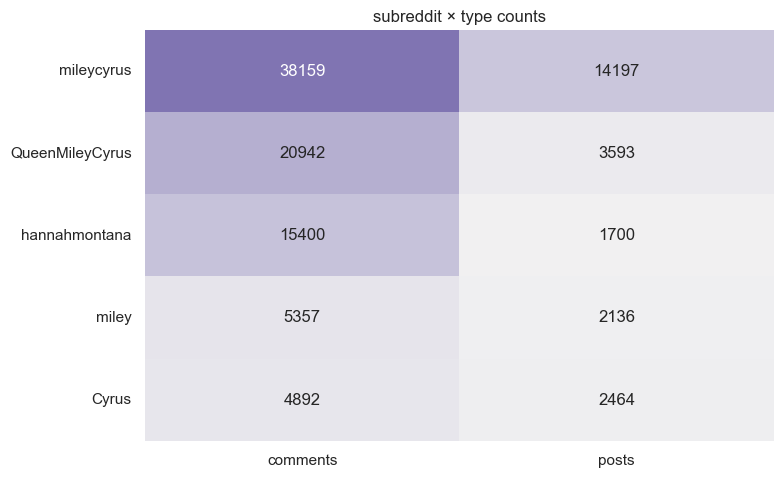

In [138]:
plt.figure(figsize=(8, 8/1.618))
sns.heatmap(
    subreddit_type_count.drop(index="TOTAL", columns="TOTAL"),
    annot=True,        # wartości w komórkach
    fmt="g",           # bez formatowania float
    cmap=sns.light_palette("#8074B2", as_cmap=True),
    cbar=False
)

plt.title("subreddit × type counts")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 2. Liczba wpisów (posty i komentarze) na każdym z subredditów

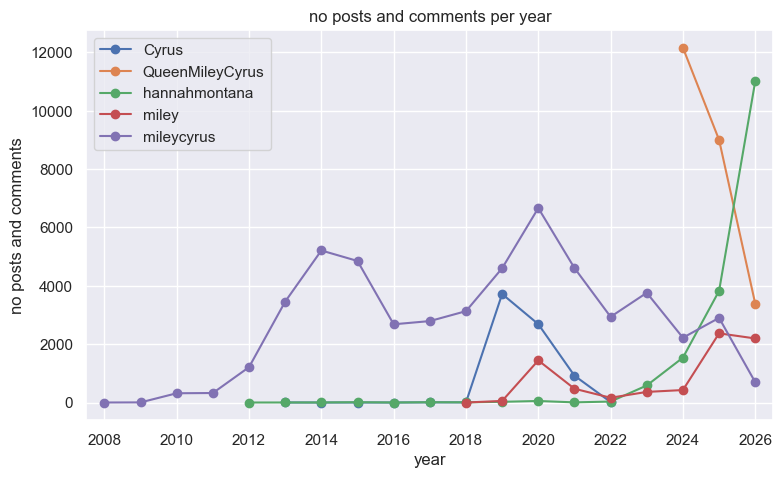

In [93]:
subreddit_time_count = (
    data.groupby(["subreddit", "year"])
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(8, 8/1.618))

for sub, group in subreddit_time_count.groupby("subreddit"):
    group = group.sort_values("year")
    ax.plot(group["year"], group["count"], marker="o", label=sub)

ax.set_title("no posts and comments per year")
ax.set_xlabel("year")
ax.set_ylabel("no posts and comments")

ax.set_xlim(2007.5, 2026.5)
ax.set_xticks(np.arange(2008, 2027, 2))

ax.legend()
plt.tight_layout()
plt.show()

In [94]:
subreddit_time_range = data.groupby("subreddit")["date"].agg(
    min_date="min",
    max_date="max"
).sort_values(by="min_date")
subreddit_time_range

,min_date,max_date
subreddit,,
mileycyrus,2008-10-30 20:12:46,2026-05-14 06:13:43
hannahmontana,2012-12-24 04:21:38,2026-05-14 16:25:52
Cyrus,2013-10-22 02:07:58,2022-01-22 08:41:08
miley,2018-07-05 09:30:21,2026-05-14 16:39:37
QueenMileyCyrus,2024-01-14 12:47:38,2026-05-14 15:27:27


## 3. Rozkład długości komentarzy i postów

Index(['Cyrus', 'mileycyrus', 'QueenMileyCyrus', 'miley', 'hannahmontana'], dtype='object', name='subreddit')


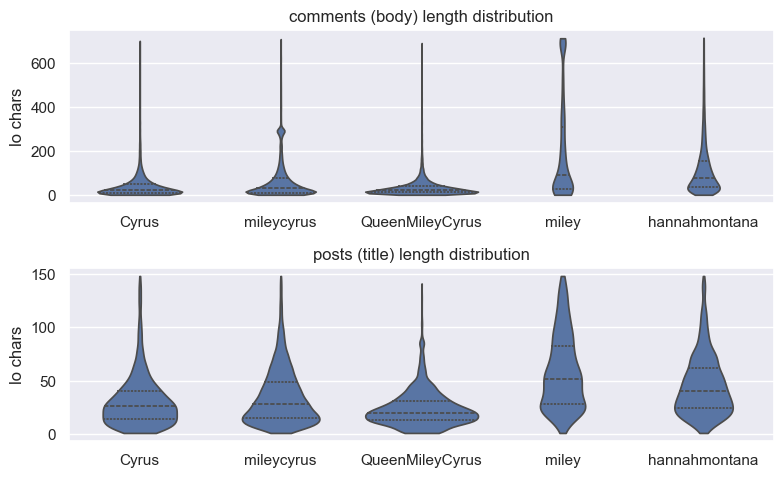

In [129]:
data["lo_body"] = data["body"].fillna("").str.len()
data["lo_title"] = data["title"].fillna("").str.len()

order = (
    data.groupby("subreddit")["lo_body"]
    .median()
    .sort_values()
    .index
)
print(order)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8/1.618))

data_body = data[
    (data["type"] == "comments") &
    (data["lo_body"] <= data["lo_body"].quantile(0.995))
]
sns.violinplot(
    data=data_body,
    x="subreddit",
    y="lo_body",
    order=order,
    cut=0,
    inner="quartile",
    ax=ax1
)

ax1.set_title("comments (body) length distribution")
ax1.set_xlabel("")
ax1.set_ylabel("lo chars")
ax1.tick_params(axis="x", rotation=0)


data_title = data[
    (data["type"] == "posts") &
    (data["lo_title"] <= data["lo_title"].quantile(0.995))
]
sns.violinplot(
    data=data_title,
    x="subreddit",
    y="lo_title",
    order=order,
    cut=0,
    inner="quartile",
    ax=ax2
)

ax2.set_title("posts (title) length distribution")
ax2.set_xlabel("")
ax2.set_ylabel("lo chars")
ax2.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 4. Liczba unikalnych autorów

In [135]:
subreddit_unique_author_count = data.pivot_table(
    index="subreddit",
    columns="type",
    values="author",
    aggfunc="nunique",
    fill_value=0
)
subreddit_unique_author_count["TOTAL"] = subreddit_unique_author_count.sum(axis=1)
subreddit_unique_author_count = subreddit_unique_author_count.sort_values(by="TOTAL", ascending=False)
subreddit_unique_author_count.loc["TOTAL"] = subreddit_unique_author_count.sum(numeric_only=True)

subreddit_unique_author_count

type,comments,posts,TOTAL
subreddit,,,
mileycyrus,8651,5321,13972
hannahmontana,4338,903,5241
Cyrus,1733,1108,2841
QueenMileyCyrus,1947,547,2494
miley,1713,461,2174
TOTAL,18382,8340,26722


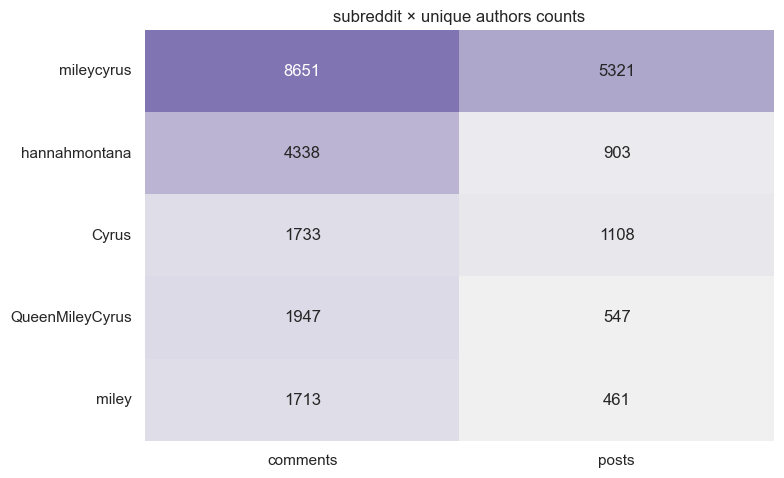

In [137]:
plt.figure(figsize=(8, 8/1.618))
sns.heatmap(
    subreddit_unique_author_count.drop(index="TOTAL", columns="TOTAL"),
    annot=True,        # wartości w komórkach
    fmt="g",           # bez formatowania float
    cmap=sns.light_palette("#8074B2", as_cmap=True),
    cbar=False
)

plt.title("subreddit × unique authors counts")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

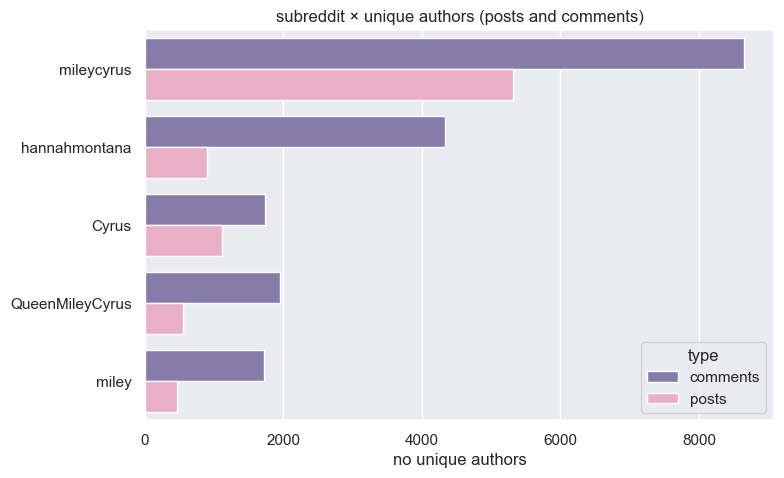

In [154]:
unique_authors_count = (
    subreddit_unique_author_count
    .drop(index="TOTAL", columns="TOTAL")
    .reset_index()
    .melt(id_vars="subreddit", var_name="type", value_name="count")
)

plt.figure(figsize=(8, 8/1.618))

sns.barplot(
    data=unique_authors_count,
    x="count",
    y="subreddit",
    hue="type",
    palette=["#8074B2", "#F2A7C3"]
)

plt.title("subreddit × unique authors (posts and comments)")
plt.xlabel("no unique authors")
plt.ylabel("")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 5. Najaktywniejsi użytkownicy (autorzy)

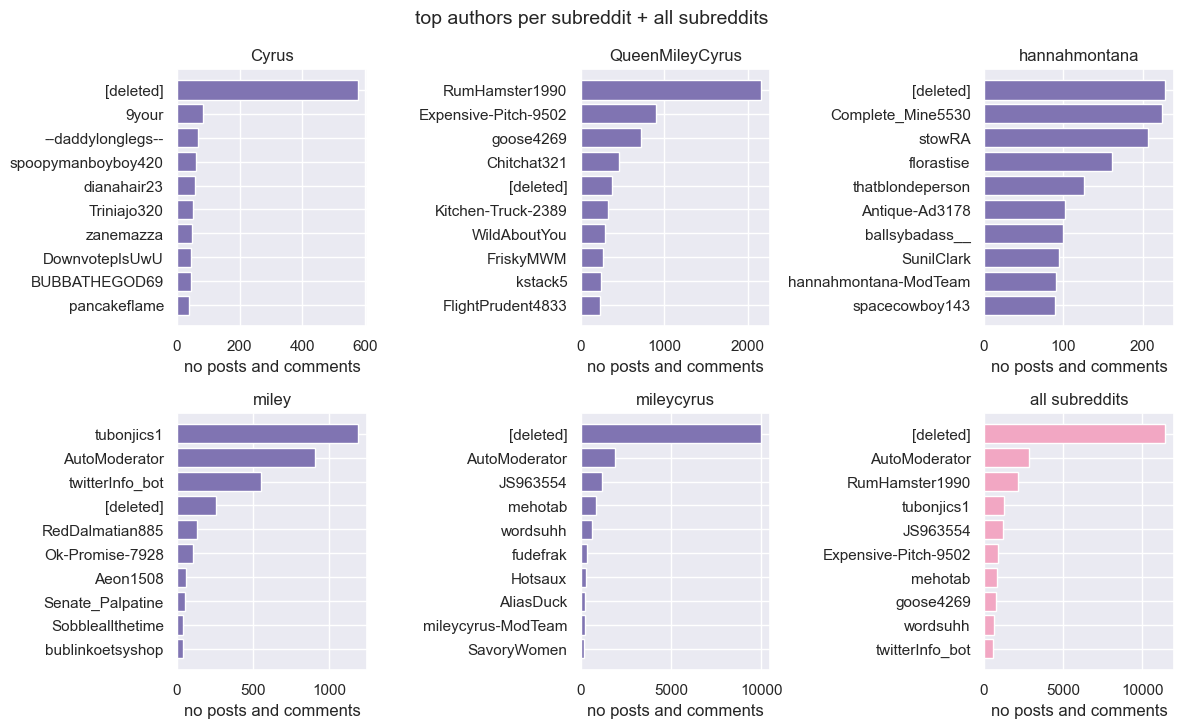

In [160]:
fig, axes = plt.subplots(2, 3, figsize=(12, 12/1.618))
fig.suptitle("top authors per subreddit + all subreddits", fontsize=14)

axes = axes.flatten()
for i, (sub, group) in enumerate(data.groupby("subreddit")):
    top = group["author"].value_counts().head(10)
    axes[i].barh(top.index[::-1], top.values[::-1], color="#8074B2")
    axes[i].set_title(f"{sub}")
    axes[i].set_xlabel("no posts and comments")

global_top = data["author"].value_counts().head(10)
axes[5].barh(
    global_top.index[::-1],
    global_top.values[::-1],
    color="#F2A7C3"
)

axes[5].set_title("all subreddits")
axes[5].set_xlabel("no posts and comments")

plt.tight_layout()
plt.show()

## 6. Ocena postów (score)

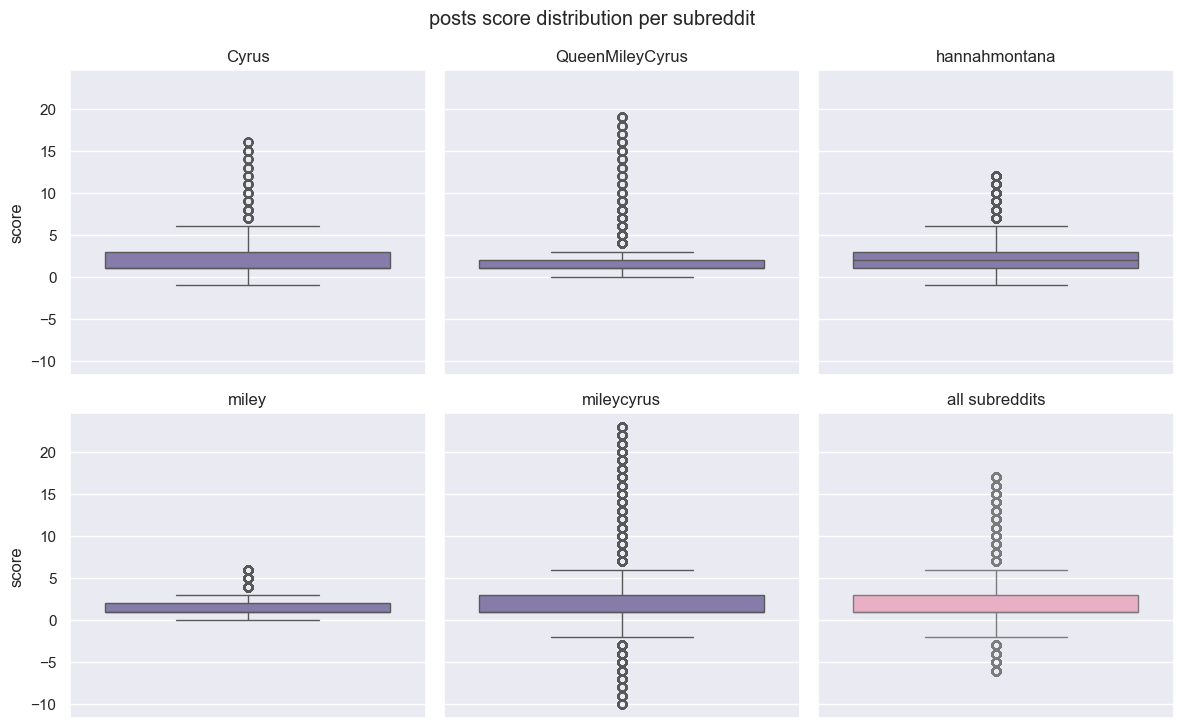

In [174]:
fig, axes = plt.subplots(2, 3, figsize=(12, 12/1.618), sharey=True)
axes = axes.flatten()

for i, (sub, group) in enumerate(data.groupby("subreddit")):
    low = group["score"].quantile(0.01)
    high = group["score"].quantile(0.90)

    filtered = group.loc[(group["score"] >= low) & (group["score"] <= high)]

    sns.boxplot(
        y=filtered["score"],
        ax=axes[i],
        color="#8074B2"
    )

    axes[i].set_title(f"{sub}")
    axes[i].set_ylabel("score")
    axes[i].set_xlabel("")


low = data["score"].quantile(0.01)
high = data["score"].quantile(0.90)

filtered = group.loc[(data["score"] >= low) & (data["score"] <= high)]

sns.boxplot(
    y=filtered["score"],
    ax=axes[5],
    color="#F2A7C3"
)

axes[5].set_title(f"all subreddits")
axes[5].set_ylabel("score")
axes[5].set_xlabel("")

plt.suptitle("posts score distribution per subreddit")
plt.tight_layout()
plt.show()